# Тематическое моделирование

In [1]:
comments_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/18.09/comments.csv'
posts_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Data/18.09/post_elections.csv'

In [2]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 32.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import string
import nltk
import re
nltk.download ('punkt')
nltk.download ('stopwords')
from nltk.corpus import stopwords
from nltk.probability import FreqDist
import  pymorphy3

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

### gensim - специализированная библиотека для работы с российским текстом для тематического моделирования

sklearn может давать лучше результат в некторых экспериментах, надо сравнивать

In [6]:
df = pd.read_csv(comments_path, index_col=0)
df.head()

,post_id,comments_text
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже..."
1,12103.0,За Бориса Борисовича Надеждина!!!
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !"
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест..."
4,12103.0,Выборы - без выбора. Вообще не за кого!!!


In [7]:
df.shape

(4754, 2)

1. Токенизация текста

In [ ]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()


In [ ]:
def tokenizer(text: str):
  # Разбиение на слова при помощи пробела
  words = text.split()
  # Подготовка регулярного выражения для фильтрации символов
  re_punc = re.compile('[%s]'%re.escape(string.punctuation))
  # Удаление знаков препинания
  stripped = [re_punc.sub('', w) for w in words]
  # Применение сверху слов к нижнему регистру
  words_lower = [w.lower() for w in stripped]
  # Удаление оставшихся токенов, которые не являются буквами
  words_alpha = [w for w in words_lower if w.isalpha()]
  # Удаление стоп слов
  words_stop = [w for w in words_alpha if not w in stop_words]
  # Лемматизация
  tokens = [morph.parse(token)[0].normal_form for token in words_stop]
  # Удаляем короткие токены
  tokens = [w for w in tokens if len(w) > 3]
  return tokens

In [ ]:
tokenized = df.comments_text.apply(tokenizer)
df  = df.assign(tokenized=tokenized)
df.head()

,post_id,comments_text,tokenized
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже...","[этот, игра, демократия, результат, итак, изве..."
1,12103.0,За Бориса Борисовича Надеждина!!!,"[борис, борисович, надеждин]"
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !","[вообще, голосовать, ярослав, ниловый]"
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест...","[интересно, выборы, пройти, честно, расклад, д..."
4,12103.0,Выборы - без выбора. Вообще не за кого!!!,"[выборы, выбор, вообще]"


# Анализ тональности

In [ ]:
!pip install dostoevsky

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.2-cp312-cp312-linux_x86_64.whl size=4463527 sha256=2d9ca20dd4054918338ca4aa707f915c95b0acd53c320745017cc9787aa1fcd8
  Stored in directory: /root/.cache/pip/wheels/3f/14/26/663abec04e7eb8ce47b13edeec3b19ad0435cf6366e27a2635
Successfully built fasttext


In [ ]:
# !python - m dostoevsky download fasttext-social-network-model

In [ ]:
# from dostoevsky.tokenization import RegexTokenizer
# from dostoevsky.models import FastTextSocialNetworkModel

In [ ]:
list_of_posts = df['tokenized'].tolist()

In [ ]:
tokens = RegexTokenizer()
model = FastTextSocialNetworkModel(tokenizer=tokenizer)
# sentiment

NameError: name 'RegexTokenizer' is not defined

# Тематическое моделирование

## Векторизация

### 1) Count Vectoriser
### 2) TF-IDF
TF — term frequency (Частота слова)

IDF — inverse document frequency (Обратная частота документа)

### CountVectorizer

In [ ]:
help(CountVectorizer)

Help on class CountVectorizer in module sklearn.feature_extraction.text:

class CountVectorizer(_VectorizerMixin, sklearn.base.BaseEstimator)
 |  CountVectorizer(*, input='content', encoding='utf-8', decode_error='strict', strip_accents=None, lowercase=True, preprocessor=None, tokenizer=None, stop_words=None, token_pattern='(?u)\\b\\w\\w+\\b', ngram_range=(1, 1), analyzer='word', max_df=1.0, min_df=1, max_features=None, vocabulary=None, binary=False, dtype=<class 'numpy.int64'>)
 |
 |  Convert a collection of text documents to a matrix of token counts.
 |
 |  This implementation produces a sparse representation of the counts using
 |  scipy.sparse.csr_matrix.
 |
 |  If you do not provide an a-priori dictionary and you do not use an analyzer
 |  that does some kind of feature selection then the number of features will
 |  be equal to the vocabulary size found by analyzing the data.
 |
 |  For an efficiency comparison of the different feature extractors, see
 |  :ref:`sphx_glr_auto_examp

In [ ]:
count_vect = CountVectorizer(max_df=0.8, min_df=3, stop_words=None)
doc_term_matrix = count_vect.fit_transform(df['tokenized'].apply(lambda x: ' '.join(x)))

In [ ]:
doc_term_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 59087 stored elements and shape (4754, 4496)>

### Латентное размещение Диркле

In [ ]:
# Класстеризация только для текста
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=3, random_state=42)

In [ ]:
LDA.components_

array([[0.3439456 , 0.33336667, 5.33330361, ..., 5.33330361, 3.02386486,
        3.7610769 ],
       [4.0835905 , 0.33339385, 0.33334828, ..., 0.33334828, 0.36602676,
        0.89204657],
       [0.57246391, 3.33323948, 0.33334811, ..., 0.33334811, 4.61010838,
        0.34687654]])

In [ ]:
for i, topic in enumerate(LDA.components_):
  print(f'Top 10 words for topic {i+1}: ')
  print([count_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
  print('\n')

Top 10 words for topic 1: 
['весь', 'свой', 'голосовать', 'народ', 'россия', 'который', 'человек', 'страна', 'грудинин', 'путин']


Top 10 words for topic 2: 
['гражданин', 'власть', 'народ', 'который', 'кандидат', 'свой', 'выборы', 'государство', 'президент', 'россия']


Top 10 words for topic 3: 
['общий', 'россия', 'быть', 'народ', 'каждый', 'который', 'человек', 'русский', 'деньга', 'свой']




In [ ]:
topic_values = LDA.transform(doc_term_matrix)

In [ ]:
topic_values.shape

(4754, 3)

In [ ]:
df['topic_LDA'] = topic_values.argmax(axis=1)
df.head()

,post_id,comments_text,tokenized,topic_LDA
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже...","[этот, игра, демократия, результат, итак, изве...",2
1,12103.0,За Бориса Борисовича Надеждина!!!,"[борис, борисович, надеждин]",0
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !","[вообще, голосовать, ярослав, ниловый]",0
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест...","[интересно, выборы, пройти, честно, расклад, д...",0
4,12103.0,Выборы - без выбора. Вообще не за кого!!!,"[выборы, выбор, вообще]",1


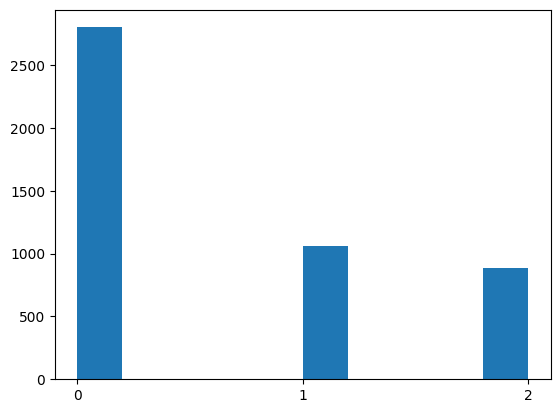

In [ ]:
plt.hist(df['topic_LDA'])
plt.xticks([0,1,2]);

In [ ]:
topic_1 = df[df['topic_LDA'] == 0]

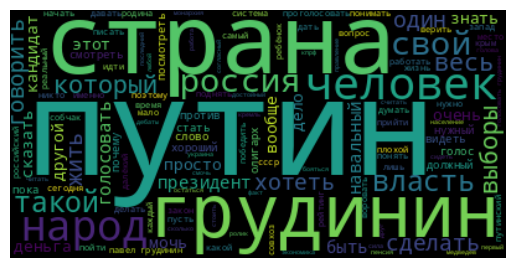

In [ ]:
text = ' '.join([' '.join(tokens) for tokens in topic_1['tokenized']])
wordcloud_img = WordCloud().generate(text)
plt.imshow(wordcloud_img, interpolation='bilinear')
plt.axis('off')
plt.show()

### TF-IDF

In [ ]:
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(df['tokenized'].apply(lambda x: ' '.join(x)))

### NMF - неотрицательная матричная факторизация

In [ ]:
nmf = NMF(n_components=2, random_state=42)
nmf.fit(doc_term_matrix)

NMF(n_components=2, random_state=42)

In [ ]:
for i, topic in enumerate(nmf.components_):
  print(f'Top 10 words for topic {i+1}: ')
  print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
  print('\n')

Top 10 words for topic 1: 
['свой', 'народ', 'человек', 'страна', 'выборы', 'навальный', 'россия', 'президент', 'голосовать', 'путин']


Top 10 words for topic 2: 
['человек', 'кандидат', 'страна', 'россия', 'выборы', 'народ', 'павел', 'голосовать', 'президент', 'грудинин']




In [ ]:
topic_values = nmf.transform(doc_term_matrix)

In [ ]:
df['topic_NMF'] = topic_values.argmax(axis=1)
df.head()

,post_id,comments_text,tokenized,topic_LDA,topic_NMF
0,12103.0,"Зачем эта игра в ""демократию"" ?! Результат уже...","[этот, игра, демократия, результат, итак, изве...",2,0
1,12103.0,За Бориса Борисовича Надеждина!!!,"[борис, борисович, надеждин]",0,0
2,12103.0,"Я бы вообще , голосовал за Ярослава Нилова !","[вообще, голосовать, ярослав, ниловый]",0,0
3,12103.0,"Интересно, если бы хоть раз выборы прошли чест...","[интересно, выборы, пройти, честно, расклад, д...",0,0
4,12103.0,Выборы - без выбора. Вообще не за кого!!!,"[выборы, выбор, вообще]",1,0


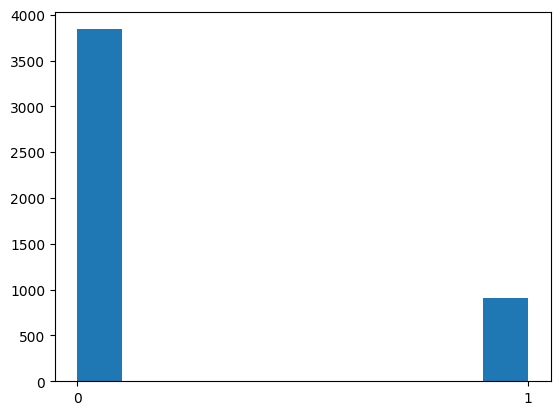

In [ ]:
plt.hist(df['topic_NMF'])
plt.xticks([0,1]);

In [ ]:
topic_1 = df[df['topic_NMF'] == 0]
topic_2 = df[df['topic_NMF'] == 1]

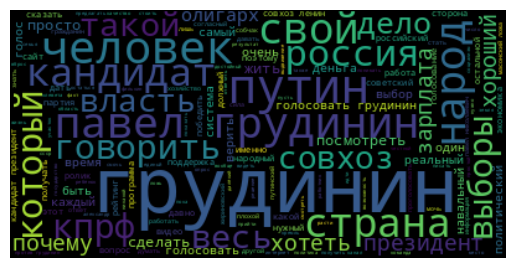

In [ ]:
text = ' '.join([' '.join(tokens) for tokens in topic_2['tokenized']])
wordcloud_img = WordCloud().generate(text)
plt.imshow(wordcloud_img, interpolation='bilinear')
plt.axis('off')
plt.show()